In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import *

In [3]:
# Load Insurance Dataset
insurance = pd.read_csv("insurance.csv")

In [4]:
# Data Understanding
insurance.shape
insurance.columns
insurance.dtypes
insurance.head()
insurance.isnull().sum()
insurance.duplicated().sum()

np.int64(1)

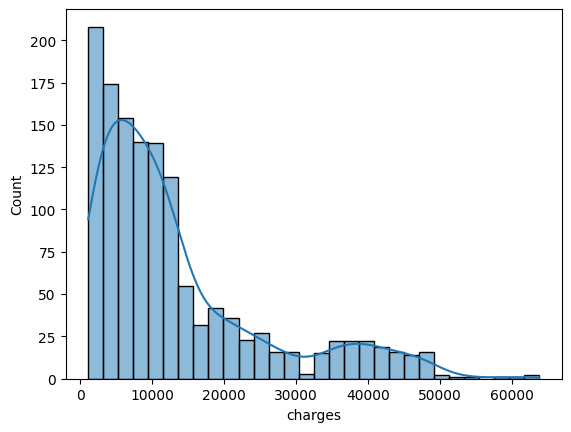

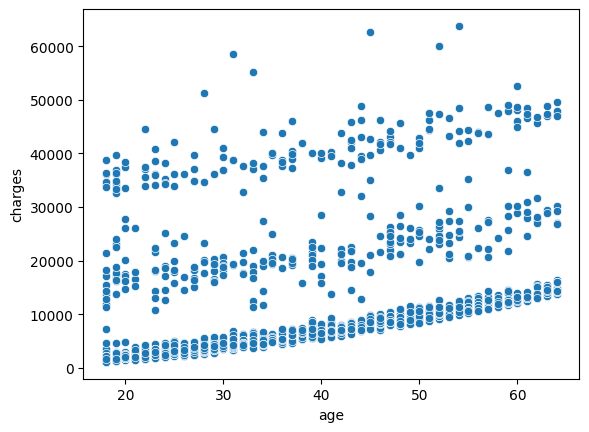

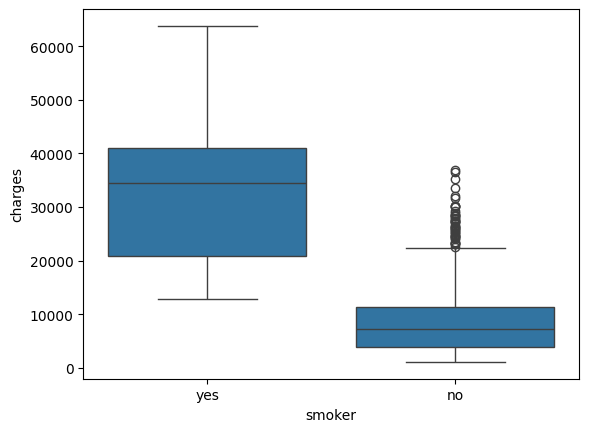

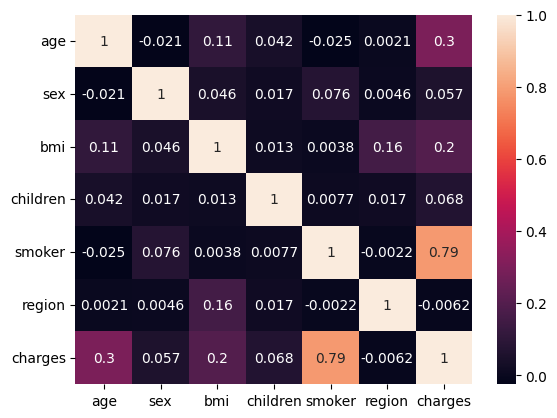

In [5]:
# EDA
# Charges Distribution
sns.histplot(insurance['charges'], kde=True)
plt.show()

# Age vs Charges
sns.scatterplot(x='age', y='charges', data=insurance)
plt.show()

# Smoker vs Charges
sns.boxplot(x='smoker', y='charges', data=insurance)
plt.show()
# Heatmap
temp = insurance.copy()
le = LabelEncoder()

temp['sex'] = le.fit_transform(temp['sex'])
temp['smoker'] = le.fit_transform(temp['smoker'])
temp['region'] = le.fit_transform(temp['region'])
sns.heatmap(temp.corr(), annot=True)
plt.show()


# Observations
1. Charges increase with age.
2. Smokers pay significantly higher charges.
3. BMI has moderate impact on charges.

In [6]:
# Encoding
le = LabelEncoder()

insurance['sex'] = le.fit_transform(insurance['sex'])
insurance['smoker'] = le.fit_transform(insurance['smoker'])
insurance['region'] = le.fit_transform(insurance['region'])

In [7]:
# X and y
X = insurance.drop('charges', axis=1)

y = insurance['charges']

In [8]:
# rain Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Scaling is applied because features have different ranges.

In [10]:
# Train Linear Regression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [11]:
# Intercept
model.intercept_

np.float64(13346.089736364485)

In [12]:
# Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,age,3616.108652
1,sex,-9.392954
2,bmi,2028.308579
3,children,516.662566
4,smoker,9557.143383
5,region,-302.387980


#Regression Equation

Charges = Intercept +
(b1 × Age) +
(b2 × Sex) +
(b3 × BMI) +
(b4 × Children) +
(b5 × Smoker) +
(b6 × Region)

In [13]:
# Prediction
y_pred = model.predict(X_test)

In [14]:
# Metrics
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

4186.508898366436
33635210.43117845
5799.5870914383595
0.7833463107364536


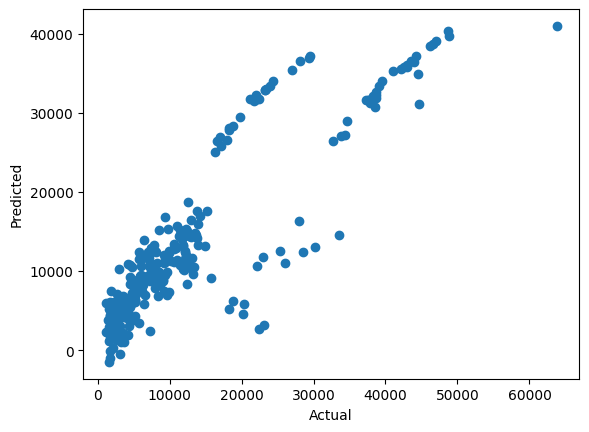

In [15]:
# Actual vs Predicted
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

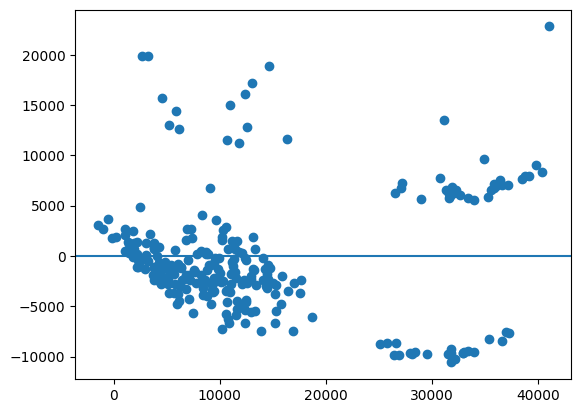

In [16]:
# Residual Plot
residuals = y_test - y_pred

plt.scatter(y_pred,residuals)

plt.axhline(y=0)

plt.show()

In [17]:
# Business Insights

coef_df.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

,Feature,Coefficient
4,smoker,9557.143383
0,age,3616.108652
2,bmi,2028.308579
3,children,516.662566
5,region,-302.387980
1,sex,-9.392954


In [ ]:
# Smoker Cost:

insurance.groupby('smoker')['charges'].mean()

# BMI Impact:

insurance[['bmi','charges']].corr()

##SECTION 1 - Data Understanding
####Observation 1::

The dataset contains demographic and medical information of insurance customers along with their medical charges.

####Observation 2::

No significant missing values or duplicate records were found in the dataset.

####Observation 3::

Both numerical and categorical features are present and require preprocessing before model training.

EDA Interpretations
Charges Distribution

Insurance charges are positively skewed. Most customers have lower charges, while a few customers have very high medical expenses.

####Age vs Charges

There is a positive relationship between age and insurance charges. Older individuals tend to have higher medical costs.

####Smoker vs Charges

Smokers incur substantially higher insurance charges than non-smokers.

####Correlation Heatmap

Smoker status shows the strongest correlation with charges. Age and BMI also contribute positively.

##SECTION 2 - Data Preprocessing
Interpretation

Categorical variables were converted into numerical values using label encoding. Data was split into training and testing sets. Feature scaling was applied to ensure all features are on a comparable scale.

Why Scaling?

Features such as age, BMI, and charges have different ranges. Scaling helps improve model stability and performance.

##SECTION 3 - Model Building
Interpretation

A Linear Regression model was trained to predict insurance charges using customer demographic and health-related information.

Regression Equation

The model estimates insurance charges as a linear combination of all input variables and their coefficients.

##SECTION 4 - Model Evaluation
MAE Interpretation

MAE represents the average difference between actual and predicted charges.

MSE Interpretation

MSE measures the average squared prediction error and penalizes larger errors.

RMSE Interpretation

RMSE provides the average prediction error in the same units as insurance charges.

####R^2 Interpretation

The R² score indicates the proportion of variance explained by the model. A higher R² value indicates better predictive performance.

####Actual vs Predicted Plot

The predictions closely follow the actual values, indicating reasonable model performance.

####Residual Plot

Residuals are randomly scattered around zero, suggesting that the model assumptions are reasonably satisfied.

##SECTION 5 - Business Insights
Which Variable Impacts Charges the Most?

Smoker status has the strongest impact on insurance charges according to the model coefficients.

###How Much More Do Smokers Pay?

The average charges for smokers are significantly higher than those for non-smokers.

###Is BMI Statistically Impactful?

BMI has a positive influence on insurance charges, indicating that higher BMI may lead to increased medical expenses.

###Can This Model Be Used in Production?

The model provides useful predictions and is easy to interpret. However, additional testing and comparison with advanced machine learning models would be recommended before production deployment.